In [4]:
#data manipulation
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#statistical analysis
import scipy.stats as stats

In [5]:
%pip install matplot seaborn scipy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv("dtdc_logistic_data.csv")

In [7]:
df.shape

(49639, 42)

In [8]:
df.info

<bound method DataFrame.info of            Origin  Destination                              Pouch No  \
0          Nagpur   Jamshedpur  55e275ad-8da9-49c9-986c-93134fef2c19   
1          Jaipur        Vizag  7fab4175-11b2-4090-a0ed-4571ccd68878   
2         Lucknow  Bhubaneswar  5231428d-b524-433e-8043-45c7e39a94aa   
3      Coimbatore       Mumbai  2f556b38-298d-4e8c-9310-4e6a3a5fbe61   
4          Meerut   Vijayawada  c3154041-34eb-435e-94d8-0900e6a9ed01   
...           ...          ...                                   ...   
49634    Varanasi       Bhopal  78ad9246-96ca-40e0-a77e-1f5f601b2114   
49635       Patna   Jamshedpur  be889bde-61ea-460c-8dc8-6bdaf7a91579   
49636     Kolkata   Aurangabad  17a77c5d-ccdf-42c1-adc0-ec5b89b84154   
49637    Srinagar   Aurangabad  9eae5dad-b5c0-4047-b1fe-a340dbc4e41e   
49638   Ahmedabad     Amritsar  fe45d57f-d3ab-4c39-b60a-8abebae5c224   

             Date                    Sender's Name  Sender Phone  \
0      2025-06-25                  

In [9]:
df.head()

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,2025-06-25,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,...,NaN,NaN,2025-06-30,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,2025-06-27,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,...,NaN,NaN,2025-06-28,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,2025-06-27,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,...,NaN,NaN,2025-06-28,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,2025-06-11,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,...,NaN,NaN,2025-06-15,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,2025-07-01,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,...,NaN,NaN,2025-07-05,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [10]:
df.columns

Index(['Origin', 'Destination', 'Pouch No', 'Date', 'Sender's Name',
       'Sender Phone', 'Sender Address', 'Sender City', 'Sender State',
       'Sender Pincode', 'Sender GSTIN', 'Total Pieces', 'Actual Wt',
       'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature',
       'Sender Date', 'Recipient Name', 'Recipient Phone', 'Recipient Address',
       'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description',
       'Value Added Services', 'Consignment No', 'Expiry Date', 'Booking Code',
       'Recipient GSTIN', 'Receiver Name', 'Relationship', 'Company Stamp',
       'Receiver Signature', 'Receive Date', 'Tariff', 'VAS Charges',
       'Total Amount', 'Mode', 'Risk Surcharge', 'Mode of Payment',
       'Nature of Consignment'],
      dtype='str')

# to print rows

In [11]:
df.shape[0]

49639

#how many columns containing null values

In [12]:
df.isnull().sum()

Origin                       0
Destination                  0
Pouch No                     0
Date                         0
Sender's Name                0
Sender Phone                 0
Sender Address               0
Sender City                  0
Sender State                 0
Sender Pincode               0
Sender GSTIN             22861
Total Pieces                 0
Actual Wt                    0
Volumetric Wt                0
Chargeable Wt                0
Paperwork                    0
Sender Signature         19828
Sender Date                  0
Recipient Name               0
Recipient Phone              0
Recipient Address            0
Recipient City               0
Receiver State               0
Receiver Pincode             0
Description                  0
Value Added Services     10240
Consignment No               0
Expiry Date                  0
Booking Code                 0
Recipient GSTIN          35773
Receiver Name                0
Relationship                 0
Company 

# to calculate how many having missing values

In [13]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values >0]
missing_values

Sender GSTIN            22861
Sender Signature        19828
Value Added Services    10240
Recipient GSTIN         35773
Company Stamp           29774
Receiver Signature      29774
dtype: int64

# to calculate duplicates

In [14]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

# to calculate how many modes are there in the dataset

In [15]:
df["Mode"].value_counts()

Mode
Surface      29699
Express       9994
Air Cargo     9946
Name: count, dtype: int64

# to calculate the percentage of the type of modes

In [16]:
df["Mode"].value_counts(normalize=True)*100

Mode
Surface      59.829972
Express      20.133363
Air Cargo    20.036665
Name: proportion, dtype: float64

# to calculate type of mode of payments

In [17]:
df["Mode of Payment"].value_counts()

Mode of Payment
Cash      29804
Card      17910
Wallet     1925
Name: count, dtype: int64

# calculate the percentage of types of mode of payments

In [18]:
df["Mode of Payment"].value_counts(normalize=True)*100

Mode of Payment
Cash      60.041500
Card      36.080501
Wallet     3.877999
Name: proportion, dtype: float64

# to calculate how many are dox and non dox here the dox represents documents

In [19]:
df["Nature of Consignment"].value_counts()

Nature of Consignment
Dox        24942
Non-Dox    24697
Name: count, dtype: int64

# dropna(False) includes the missing values in the count

In [20]:
df["Value Added Services"].value_counts(dropna=False)

Value Added Services
COD          29565
NaN          10240
Express       4941
Insurance     4893
Name: count, dtype: int64

# columns that contains the str "DATE"

In [21]:
df.columns[df.columns.str.contains("Date",case=False,na=False)]

Index(['Date', 'Sender Date', 'Expiry Date', 'Receive Date'], dtype='str')

# it is stored in date_columns

In [22]:
date_columns =df.columns[df.columns.str.contains("Date",case=False,na=False)]
date_columns

Index(['Date', 'Sender Date', 'Expiry Date', 'Receive Date'], dtype='str')

# to print top 10

In [23]:
df[date_columns].head(10)

,Date,Sender Date,Expiry Date,Receive Date
0,2025-06-25,2025-06-25,2025-07-25,2025-06-30
1,2025-06-27,2025-06-27,2025-07-27,2025-06-28
2,2025-06-27,2025-06-27,2025-07-27,2025-06-28
3,2025-06-11,2025-06-11,2025-07-11,2025-06-15
4,2025-07-01,2025-07-01,2025-07-31,2025-07-05
5,2025-06-16,2025-06-16,2025-07-16,2025-06-19
6,2025-06-07,2025-06-07,2025-07-07,2025-06-10
7,2025-06-23,2025-06-23,2025-07-23,2025-06-28
8,2025-06-30,2025-06-30,2025-07-30,2025-07-04
9,2025-06-26,2025-06-26,2025-07-26,2025-06-27


# to know the  type of datatype in date_columns

In [24]:
df[date_columns].dtypes

Date            str
Sender Date     str
Expiry Date     str
Receive Date    str
dtype: object

# to check late deliveries it is not possible to check for str values temporarily the values of "Date" , "Receive Date " are turned into "Datetime"so , check for the columns where receive date is less than sendind date 

In [25]:
date_check = df[["Date","Receive Date"]].apply(pd.to_datetime)
(date_check["Receive Date"]<date_check["Date"]).sum()

np.int64(0)

In [26]:
date_check = df[["Date" ,"Sender Date", "Receive Date" , "Expiry Date"]].apply(pd.to_datetime)
(date_check["Receive Date"] > date_check["Expiry Date"]).sum()


np.int64(0)

# to check whether the "Date" and "Sender Date" is same or not


In [27]:
(date_check["Date"] != date_check["Sender Date"]).sum()


np.int64(0)

In [28]:
(date_check["Expiry Date"]-date_check["Date"]).value_counts()

30 days    49639
Name: count, dtype: int64

# calculating hownmany days it is taking to receive the prodect 

In [29]:
delivery_days = (date_check["Receive Date"] - date_check["Date"])
delivery_days.describe()

count                     49639
mean     2 days 23:57:04.202743
std      1 days 09:50:01.460635
min             1 days 00:00:00
25%             2 days 00:00:00
50%             3 days 00:00:00
75%             4 days 00:00:00
max             5 days 00:00:00
dtype: object

# through sort_index we can easily understand the actual differentiation of the dates 
  it will arrange as per the counts

In [30]:
delivery_days.value_counts().sort_index()

1 days     9881
2 days     9923
3 days    10060
4 days     9966
5 days     9809
Name: count, dtype: int64

# numeric digit classification
# select column whose datatype is number 
-in logistic dataset contains different kinds of data 
such as :
text
categories 
numerical
date

-once we know which columns are numerical and we can investiga the stts mean, median , min ,max
-it is mandatory to check what are the numerical columns to validate and calculate statistics and can validate to which categories we should make calculations 

In [31]:
numeric_columns = df.select_dtypes(include ="number").columns
numeric_columns

Index(['Sender Phone', 'Sender Pincode', 'Total Pieces', 'Actual Wt',
       'Volumetric Wt', 'Chargeable Wt', 'Recipient Phone', 'Receiver Pincode',
       'Tariff', 'VAS Charges', 'Total Amount'],
      dtype='str')

- describe is used to calculates statistics such as count, mean, standard deviation, minimum, maximum and quartiles.

- "T" is transpose it change row as column so we can easily understand the table

In [32]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sender Phone,49639.0,5.010054e+09,2.892645e+09,17108.00,2.479984e+09,5.018929e+09,7.533459e+09,9.999872e+09
Sender Pincode,49639.0,4.997865e+05,2.886076e+05,1.00,2.481975e+05,4.994790e+05,7.483220e+05,9.999810e+05
Total Pieces,49639.0,2.994480e+00,1.415086e+00,1.00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Actual Wt,49639.0,6.167263e+00,3.375089e+00,0.30,3.260000e+00,6.190000e+00,9.080000e+00,1.200000e+01
Volumetric Wt,49639.0,7.716568e+00,3.476748e+00,0.44,4.800000e+00,7.740000e+00,1.064000e+01,1.497000e+01
Chargeable Wt,49639.0,7.716568e+00,3.476748e+00,0.44,4.800000e+00,7.740000e+00,1.064000e+01,1.497000e+01
Recipient Phone,49639.0,4.973767e+09,2.883664e+09,228920.00,2.473943e+09,4.960678e+09,7.459426e+09,9.999958e+09
Receiver Pincode,49639.0,5.005479e+05,2.878514e+05,2.00,2.520650e+05,5.023200e+05,7.492295e+05,9.999730e+05
Tariff,49639.0,4.408541e+02,2.431882e+02,19.90,2.550400e+02,4.099800e+02,5.715700e+02,1.372900e+03
VAS Charges,49639.0,6.719894e+01,4.789943e+01,0.00,2.730500e+01,6.745000e+01,1.088600e+02,1.500000e+02


# weight classification
we have three types of weights 
-actual weight : it is the weight of the product :6 kgs
-volumetric weight : it includes parcel weight  : 8kgs
-chargeable weight : it is the weight which is used as per records : 8kgs

*so in this step we checked whether the chargable weight is same of volumetric weight so all the products are having correct chargable weight 

In [33]:
df[["Actual Wt" , "Volumetric Wt" , "Chargeable Wt"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Actual Wt,49639.0,6.167263,3.375089,0.30,3.26,6.19,9.08,12.00
Volumetric Wt,49639.0,7.716568,3.476748,0.44,4.80,7.74,10.64,14.97
Chargeable Wt,49639.0,7.716568,3.476748,0.44,4.80,7.74,10.64,14.97


In [34]:
(df["Chargeable Wt"] == df["Volumetric Wt"]).all()

np.True_

in this step we check whether the actual weight is greater than volumetric weight acroos all the columns 

- so out put shows 0 so, we can conclude that all the wt records are correct

In [35]:
(df["Actual Wt"] > df["Volumetric Wt"]).sum()

np.int64(0)

# Check financial values

In [36]:
df[["Tariff", "VAS Charges", "Total Amount"]].min()

Tariff          19.90
VAS Charges      0.00
Total Amount    22.63
dtype: float64

- checks whether the total amount is greater than or equal to "tarif + vas charges"

In [37]:
id="n8j3pk"
(df["Total Amount"] >= df["Tariff"] + df["VAS Charges"]).mean()

np.float64(0.9129515099014888)

-to check  how many shipments actually fail the condition.

In [38]:
invalid_Amount_Count = (df["Total Amount"] < df["Tariff"] + df["VAS Charges"]).sum()
invalid_Amount_Count

np.int64(4321)

In [39]:
df["Total Pieces"].value_counts().sort_index()

Total Pieces
1    10007
2     9947
3     9867
4     9949
5     9869
Name: count, dtype: int64

In [40]:
df[
    df["Total Amount"] < df["Tariff"] + df["VAS Charges"]
][["Tariff", "VAS Charges", "Total Amount", "Risk Surcharge"]].head(10)

,Tariff,VAS Charges,Total Amount,Risk Surcharge
38,637.82,63.56,701.38,Carrier
50,900.97,49.33,950.30,Carrier
54,164.55,144.28,308.83,Carrier
68,441.68,129.75,571.43,Carrier
71,341.36,25.98,367.34,Carrier
80,742.84,97.71,840.55,Carrier
92,316.47,148.85,465.32,Carrier
97,315.04,78.67,393.71,Carrier
116,1095.38,105.24,1200.62,Carrier
132,534.69,147.47,682.16,Carrier


In [45]:
amount_difference = (
    df["Total Amount"]
    - df["Tariff"]
    - df["VAS Charges"]
)

amount_difference.describe()

count    4.963900e+04
mean     6.677576e-17
std      3.303828e-14
min     -2.131628e-13
25%     -1.421085e-14
50%      0.000000e+00
75%      1.421085e-14
max      2.273737e-13
dtype: float64

# outlier
An outlier is a value that is unusually high or low compared with most other values.

For example, if shipment weights are:

2.1, 3.5, 4.2, 5.0, 5.8, 6.2, 45.0

45.0 may be an outlier

# A quantile tells us the value below which a certain percentage of the data falls.
Q1 = 3.26 kg

So approximately 25% of shipments have Actual Weight at or below 3.26 kg.

In [46]:
Q1 = df["Actual Wt"].quantile(0.25)
Q3 = df["Actual Wt"].quantile(0.75)

Q1, Q3

(np.float64(3.26), np.float64(9.08))

IQR = Interquartile Range

It measures the spread of the middle 50% of our data.

In [47]:
IQR = Q3 - Q1
IQR

np.float64(5.82)

In [52]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

lower_bound, upper_bound

(np.float64(-5.470000000000001), np.float64(17.810000000000002))

In [53]:
outlier_count = (
    (df["Actual Wt"] < lower_bound) |
    (df["Actual Wt"] > upper_bound)
).sum()

outlier_count

np.int64(0)

In [92]:
Q1_tariff = df["Tariff"].quantile(0.25)
Q3_tariff = df["Tariff"].quantile(0.75)

IQR_tariff = Q3_tariff - Q1_tariff

lower_bound_tariff =Q1_tariff -(1.5*IQR_tariff)
upper_bound_tariff =Q3_tariff +(1.5*IQR_tariff)

outlier_count_tariff = ((df["Tariff"]<lower_bound_tariff )| (df["Tariff"]>upper_bound_tariff)).sum()

outlier_count_tariff

np.int64(1112)

In [79]:
df[
    (df["Tariff"] < lower_bound_tariff) |
    (df["Tariff"] > upper_bound_tariff)
][["Tariff"]].head(10)

,Tariff
3,1162.00
116,1095.38
119,1070.27
130,1179.56
208,1065.94
303,1093.26
318,1134.92
344,1096.52
398,1109.11
462,1056.89


In [91]:
Q1_total_amount = df["Total Amount"].quantile(0.25)
Q3_total_amount = df["Total Amount"].quantile(0.75)

IQR_total_amount = Q3_total_amount - Q1_total_amount

lower_bound_total_amount = Q1_total_amount -(1.5 * IQR_total_amount)
upper_bound_total_amount = Q3_total_amount +(1.5 * IQR_total_amount)

outiler_count_total_amount = ((df["Total Amount"]<lower_bound_total_amount)| (df["Total Amount"]>upper_bound_total_amount)).sum()

outiler_count_total_amount


np.int64(1011)

In [88]:
df[
    (df["Total Amount"] < lower_bound_total_amount) |
    (df["Total Amount"] > upper_bound_total_amount)
][["Total Amount"]].head(10)

,Total Amount
3,1187.23
116,1200.62
119,1210.23
130,1327.77
208,1189.93
318,1235.07
344,1206.89
372,1162.86
398,1153.31
478,1138.46


In [89]:
Q1_vas = df["VAS Charges"].quantile(0.25)
Q3_vas = df["VAS Charges"].quantile(0.75)

IQR_vas = Q3_vas - Q1_vas

lower_bound_vas = Q1_vas - (1.5 * IQR_vas)
upper_bound_vas = Q3_vas + (1.5 * IQR_vas)

outlier_count_vas = (
    (df["VAS Charges"] < lower_bound_vas) |
    (df["VAS Charges"] > upper_bound_vas)
).sum()

outlier_count_vas

np.int64(0)

In [90]:
Q1_vol = df["Volumetric Wt"].quantile(0.25)
Q3_vol = df["Volumetric Wt"].quantile(0.75)

IQR_vol = Q3_vol - Q1_vol

lower_bound_vol = Q1_vol - (1.5 * IQR_vol)
upper_bound_vol = Q3_vol + (1.5 * IQR_vol)

outlier_count_vol = (
    (df["Volumetric Wt"] < lower_bound_vol) |
    (df["Volumetric Wt"] > upper_bound_vol)
).sum()

outlier_count_vol

np.int64(0)

# Data Cleaning & Preparation

-Decide which columns to remove

df.columns gives us the column names, while . # tolist() converts them into a normal Python list so they're easier to read and work with.

In [93]:
df.columns.tolist()

['Origin',
 'Destination',
 'Pouch No',
 'Date',
 "Sender's Name",
 'Sender Phone',
 'Sender Address',
 'Sender City',
 'Sender State',
 'Sender Pincode',
 'Sender GSTIN',
 'Total Pieces',
 'Actual Wt',
 'Volumetric Wt',
 'Chargeable Wt',
 'Paperwork',
 'Sender Signature',
 'Sender Date',
 'Recipient Name',
 'Recipient Phone',
 'Recipient Address',
 'Recipient City',
 'Receiver State',
 'Receiver Pincode',
 'Description',
 'Value Added Services',
 'Consignment No',
 'Expiry Date',
 'Booking Code',
 'Recipient GSTIN',
 'Receiver Name',
 'Relationship',
 'Company Stamp',
 'Receiver Signature',
 'Receive Date',
 'Tariff',
 'VAS Charges',
 'Total Amount',
 'Mode',
 'Risk Surcharge',
 'Mode of Payment',
 'Nature of Consignment']

# Convert date columns to datetime

-Our four date columns are:

Date
Sender Date
Expiry Date
Receive Date

In [95]:
date_columns = ["Date" , "Sender Date" , "Expiry Date" , "Receive Date"]
df[date_columns] = df[date_columns].apply(pd.to_datetime)

# removing the sender and receiver signature because it has null values and it is not useful for our analysis

In [98]:
df = df.drop(columns  =["Sender Signature" , "Receiver Signature"])

In [100]:
df.columns.tolist()

['Origin',
 'Destination',
 'Pouch No',
 'Date',
 "Sender's Name",
 'Sender Phone',
 'Sender Address',
 'Sender City',
 'Sender State',
 'Sender Pincode',
 'Sender GSTIN',
 'Total Pieces',
 'Actual Wt',
 'Volumetric Wt',
 'Chargeable Wt',
 'Paperwork',
 'Sender Date',
 'Recipient Name',
 'Recipient Phone',
 'Recipient Address',
 'Recipient City',
 'Receiver State',
 'Receiver Pincode',
 'Description',
 'Value Added Services',
 'Consignment No',
 'Expiry Date',
 'Booking Code',
 'Recipient GSTIN',
 'Receiver Name',
 'Relationship',
 'Company Stamp',
 'Receive Date',
 'Tariff',
 'VAS Charges',
 'Total Amount',
 'Mode',
 'Risk Surcharge',
 'Mode of Payment',
 'Nature of Consignment']

# Remove the GSTIN columns

We already decided that these are not needed for our delivery-performance analysis:

In [101]:
df = df.drop(columns=["Sender GSTIN", "Recipient GSTIN"])

In [102]:
df.shape

(49639, 38)

In [103]:
df = df.drop(columns=["Company Stamp"])

- Check VAS against VAS Charges

In [104]:
df.groupby("Value Added Services")["VAS Charges"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
Value Added Services,,,,
COD,29565,20.02,150.00,84.627291
Express,4941,20.01,149.98,85.150049
Insurance,4893,20.07,149.96,84.397259


In [105]:
df.groupby("Value Added Services", dropna=False)["VAS Charges"].agg(
    ["count", "min", "max", "mean"]
)

,count,min,max,mean
Value Added Services,,,,
COD,29565,20.02,150.00,84.627291
Express,4941,20.01,149.98,85.150049
Insurance,4893,20.07,149.96,84.397259
NaN,10240,0.00,0.00,0.000000


In [106]:
df["Value Added Services"] = df["Value Added Services"].fillna("No VAS")

In [107]:
df["Value Added Services"].value_counts()

Value Added Services
COD          29565
No VAS       10240
Express       4941
Insurance     4893
Name: count, dtype: int64

- should remove "Sender Phone", "Recipient Phone"

In [108]:
df = df.drop(columns=["Sender Phone", "Recipient Phone"])

In [109]:
df.shape

(49639, 35)

We started with 42 coulmns:

Removed 2 signatures → 40
Removed 2 GSTIN columns → 38
Removed Company Stamp → 37
Removed 2 phone columns → 35

In [110]:
df[["Sender Pincode", "Receiver Pincode"]].dtypes

Sender Pincode      int64
Receiver Pincode    int64
dtype: object

In [111]:
df["Sender Pincode"] = df["Sender Pincode"].astype(str)
df["Receiver Pincode"] = df["Receiver Pincode"].astype(str)

In [112]:
df[["Sender Pincode", "Receiver Pincode"]].dtypes

Sender Pincode      str
Receiver Pincode    str
dtype: object

In [ ]:
# this will show every distinct value in the Mode column.

# unique() returns the different values/categories present in that column.

In [113]:
df["Mode"].unique()

<StringArray>
['Express', 'Surface', 'Air Cargo']
Length: 3, dtype: str

In [114]:
df["Mode of Payment"].unique()

<StringArray>
['Cash', 'Card', 'Wallet']
Length: 3, dtype: str

In [115]:
df["Nature of Consignment"].unique()

<StringArray>
['Dox', 'Non-Dox']
Length: 2, dtype: str

In [116]:
categorical_columns = [
    "Mode",
    "Mode of Payment",
    "Nature of Consignment",
    "Value Added Services",
    "Risk Surcharge"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].astype(str).str.strip().unique())


Mode:
<StringArray>
['Express', 'Surface', 'Air Cargo']
Length: 3, dtype: str

Mode of Payment:
<StringArray>
['Cash', 'Card', 'Wallet']
Length: 3, dtype: str

Nature of Consignment:
<StringArray>
['Dox', 'Non-Dox']
Length: 2, dtype: str

Value Added Services:
<StringArray>
['COD', 'Express', 'Insurance', 'No VAS']
Length: 4, dtype: str

Risk Surcharge:
<StringArray>
['Carrier', 'Owner']
Length: 2, dtype: str


In [117]:
df.shape


(49639, 35)

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Origin                 49639 non-null  str           
 1   Destination            49639 non-null  str           
 2   Pouch No               49639 non-null  str           
 3   Date                   49639 non-null  datetime64[us]
 4   Sender's Name          49639 non-null  str           
 5   Sender Address         49639 non-null  str           
 6   Sender City            49639 non-null  str           
 7   Sender State           49639 non-null  str           
 8   Sender Pincode         49639 non-null  str           
 9   Total Pieces           49639 non-null  int64         
 10  Actual Wt              49639 non-null  float64       
 11  Volumetric Wt          49639 non-null  float64       
 12  Chargeable Wt          49639 non-null  float64       
 13  Paperwork   

In [ ]:
# check for the null values ( its just a reinvestigation)

In [119]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [120]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# till now whole data is stored in dataframe and all the changes which we did till now will not applicable to the original csv file so , this move make the changes will applies to the original csv file.

# Now the cleaned dataset physically exists as a file.
# So if tomorrow you open your project again, you don't have to repeat all the cleaning steps.

In [121]:
df.to_csv("dtdc_logistics_cleaned.csv", index=False)

In [ ]:
# this is the time to understand the new dataset......

In [122]:
df.head()

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Address,Sender City,Sender State,Sender Pincode,Total Pieces,...,Receiver Name,Relationship,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,2025-06-25,Megha Majumdar,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,5,...,Benjamin Kalla,Family,2025-06-30,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,2025-06-27,Nanda-Saraf,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,5,...,Qushi Goyal,Self,2025-06-28,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,2025-06-27,Contractor LLC,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,3,...,Siddharth Gera,Friend,2025-06-28,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,2025-06-11,Krishna Hans,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,4,...,Manbir Chakraborty,Friend,2025-06-15,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,2025-07-01,Kuruvilla-Tiwari,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,3,...,Sachi Bora,Friend,2025-07-05,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [124]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,49639,2025-06-20 12:24:00.319104,2025-06-06 00:00:00,2025-06-13 00:00:00,2025-06-21 00:00:00,2025-06-28 00:00:00,2025-07-05 00:00:00,NaN
Total Pieces,49639.0,2.99448,1.0,2.0,3.0,4.0,5.0,1.415086
Actual Wt,49639.0,6.167263,0.3,3.26,6.19,9.08,12.0,3.375089
Volumetric Wt,49639.0,7.716568,0.44,4.8,7.74,10.64,14.97,3.476748
Chargeable Wt,49639.0,7.716568,0.44,4.8,7.74,10.64,14.97,3.476748
Sender Date,49639,2025-06-20 12:24:00.319104,2025-06-06 00:00:00,2025-06-13 00:00:00,2025-06-21 00:00:00,2025-06-28 00:00:00,2025-07-05 00:00:00,NaN
Expiry Date,49639,2025-07-20 12:24:00.319104,2025-07-06 00:00:00,2025-07-13 00:00:00,2025-07-21 00:00:00,2025-07-28 00:00:00,2025-08-04 00:00:00,NaN
Receive Date,49639,2025-06-23 12:21:04.521847,2025-06-07 00:00:00,2025-06-16 00:00:00,2025-06-23 00:00:00,2025-07-01 00:00:00,2025-07-10 00:00:00,NaN
Tariff,49639.0,440.854079,19.9,255.04,409.98,571.57,1372.9,243.188225
VAS Charges,49639.0,67.198937,0.0,27.305,67.45,108.86,150.0,47.89943


In [125]:
df["Mode"].value_counts()

Mode
Surface      29699
Express       9994
Air Cargo     9946
Name: count, dtype: int64

In [126]:
df["Mode"].value_counts(normalize=True)*100

Mode
Surface      59.829972
Express      20.133363
Air Cargo    20.036665
Name: proportion, dtype: float64

In [128]:
df["Delivery Days"] = (df["Receive Date"] - df["Sender Date"]).dt.days
df["Delivery Days"].describe()

count    49639.000000
mean         2.997965
std          1.409739
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Delivery Days, dtype: float64

In [ ]:
# Delivery time by Mode
# Does the shipping mode have a different average delivery time?

In [129]:
df.groupby("Mode")["Delivery Days"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Mode,,,,,
Air Cargo,9946,2.986125,3.0,1,5
Express,9994,3.009105,3.0,1,5
Surface,29699,2.998182,3.0,1,5


- City-level delivery performance

#This gives us the top 10 sender cities by shipment volume and their average delivery time

In [132]:
df.groupby("Sender City")["Delivery Days"].agg(["count", "mean"]).sort_values("count",ascending=False).head(10)

,count,mean
Sender City,,
Patna,1464,2.993852
Vijayawada,1450,2.989655
Pune,1426,2.998597
Delhi,1420,2.999296
Surat,1415,2.983039
Nagpur,1409,2.999290
Mumbai,1407,2.992893
Vizag,1404,3.047721
Ranchi,1402,3.075606


 - Delivery performance by Mode of Payment

In [133]:
df.groupby("Mode of Payment")["Delivery Days"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False)

,count,mean,median
Mode of Payment,,,
Cash,29804,2.997282,3.0
Card,17910,2.994752,3.0
Wallet,1925,3.038442,3.0


- Revenue by Mode

In [134]:
df.groupby("Mode")["Total Amount"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)

,count,sum,mean
Mode,,,
Surface,29699,12274515.33,413.297260
Express,9994,7272062.67,727.642853
Air Cargo,9946,5672665.67,570.346438


- Weight vs Total Amount
This calculates the correlation between actual weight and total shipment amount.

In [137]:
df[["Actual Wt" , "Total Amount"]].corr()

,Actual Wt,Total Amount
Actual Wt,1.000000,0.782742
Total Amount,0.782742,1.000000


In [ ]:
#  to visulaize this 

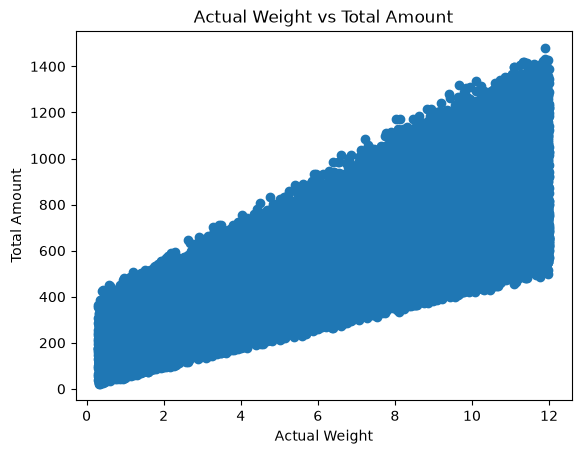

In [138]:
plt.scatter(df["Actual Wt"], df["Total Amount"])
plt.xlabel("Actual Weight")
plt.ylabel("Total Amount")
plt.title("Actual Weight vs Total Amount")
plt.show()

# Delivery performance by Consignment Type

We have:

Dox
Non-Dox

These can be compared on shipment volume, average delivery time, and average amount.

In [139]:
df.groupby("Nature of Consignment").agg(
    Shipments=("Pouch No", "count"),
    Avg_Delivery_Days=("Delivery Days", "mean"),
    Avg_Total_Amount=("Total Amount", "mean")
)

,Shipments,Avg_Delivery_Days,Avg_Total_Amount
Nature of Consignment,,,
Dox,24942,2.997153,510.082659
Non-Dox,24697,2.998785,506.003239


# Top sender cities

In [140]:
df["Sender City"].value_counts().head(10)

Sender City
Patna         1464
Vijayawada    1450
Pune          1426
Delhi         1420
Surat         1415
Nagpur        1409
Mumbai        1407
Vizag         1404
Ranchi        1402
Ahmedabad     1401
Name: count, dtype: int64

In [ ]:
# Top sender cities + delivery performance

In [141]:
df.groupby("Sender City").agg(
    Shipments=("Pouch No", "count"),
    Avg_Delivery_Days=("Delivery Days", "mean")
).sort_values("Shipments", ascending=False).head(10)

,Shipments,Avg_Delivery_Days
Sender City,,
Patna,1464,2.993852
Vijayawada,1450,2.989655
Pune,1426,2.998597
Delhi,1420,2.999296
Surat,1415,2.983039
Nagpur,1409,2.999290
Mumbai,1407,2.992893
Vizag,1404,3.047721
Ranchi,1402,3.075606


# KPI metrics

- These will useful for  Power BI dashboard

- These four KPIs give us:

Total Shipments | Average Delivery Days | Total Revenue | Average Shipment Value.

In [142]:
total_shipments = len(df)
avg_delivery_days = df["Delivery Days"].mean()
total_revenue = df["Total Amount"].sum()
avg_shipment_value = df["Total Amount"].mean()

total_shipments, avg_delivery_days, total_revenue, avg_shipment_value

(49639,
 np.float64(2.9979653095348415),
 np.float64(25219243.67),
 np.float64(508.0530161767965))

Shipment distribution by Mode

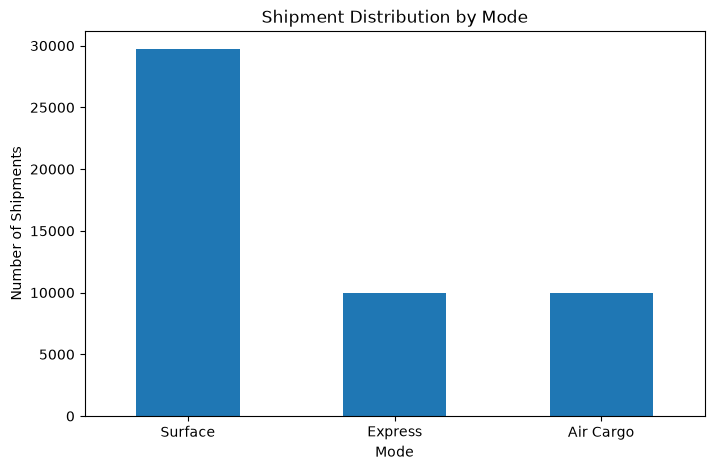

In [143]:
plt.figure(figsize=(8, 5))
df["Mode"].value_counts().plot(kind="bar")
plt.title("Shipment Distribution by Mode")
plt.xlabel("Mode")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.show()

Delivery Days distribution

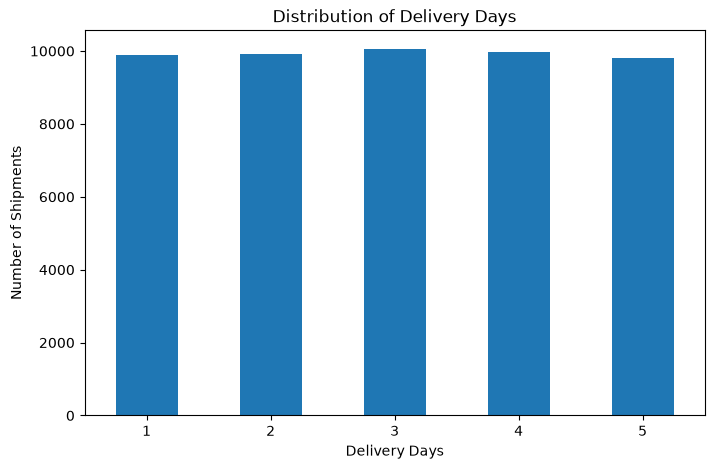

In [144]:
plt.figure(figsize=(8, 5))
df["Delivery Days"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.show()

Average Delivery Days by Mode

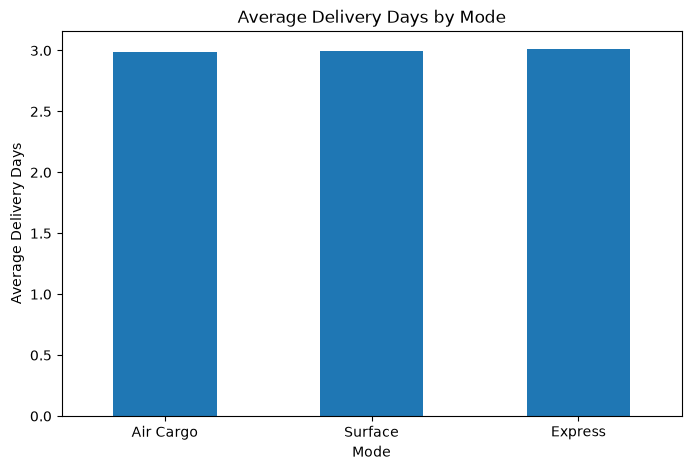

In [145]:
plt.figure(figsize=(8, 5))
df.groupby("Mode")["Delivery Days"].mean().sort_values().plot(kind="bar")
plt.title("Average Delivery Days by Mode")
plt.xlabel("Mode")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=0)
plt.show()

Revenue by Mode

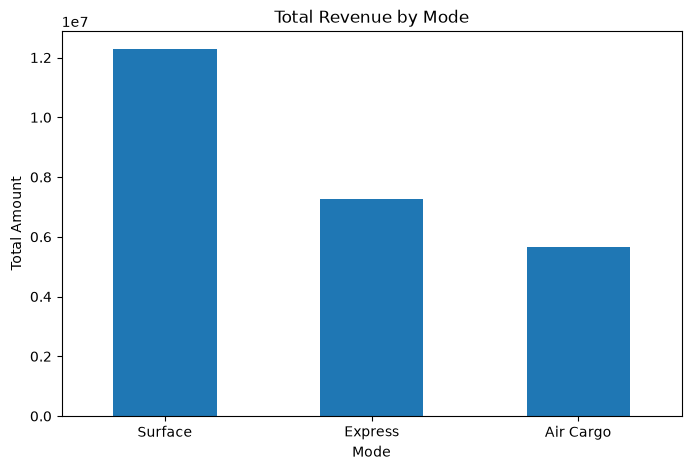

In [146]:
plt.figure(figsize=(8, 5))
df.groupby("Mode")["Total Amount"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Revenue by Mode")
plt.xlabel("Mode")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.show()